In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# --- Configuration ---
# Environment (Original 11x5 grid for discovery)
GRID_HEIGHT = 10
GRID_WIDTH = 20
WALL_X = 11
DOOR_POS_PS = (11, 5)  # Problem-space door coordinate (x, y)

# SR & Eigenoption Params
SR_GAMMA = 0.99
SR_ETA = 0.1
SR_EPISODES = 500
EPISODE_LENGTH = 200

# Option Policy Learning
OPT_GAMMA = 0.9
OPT_ALPHA = 0.1
OPT_EPSILON_START = 1.0
OPT_EPSILON_END = 0.01
OPT_EPSILON_DECAY = 0.999
OPT_EPISODES = 5000 # Increased episodes for better policy

# Manual Goal for Visualization (Our "Clean" Termination)
MANUAL_GOAL_AGS = (2, 0) # Agent-space goal (dx, dy)

# Output filename
SKILL_FILENAME = "hybrid_portable_skill.npy"


class TrainingEnv:
    """The 11x5 environment used for discovering the skill."""
    def __init__(self, width, height, wall_x, door_pos_ps):
        self.width = width
        self.height = height
        self.wall_x = wall_x
        self.door_pos_ps = door_pos_ps
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)} # L, R, U, D
        self.action_arrows = {0: '←', 1: '→', 2: '↑', 3: '↓'}
        self._build_mappings()
        self.num_ps_states = len(self.id_to_ps)
        self.num_ags_states = len(self.id_to_ags)
        print(f"Training Env (11x5) Initialized:")
        print(f"  Problem-Space (PS) States: {self.num_ps_states}")
        print(f"  Agent-Space (AGS) States: {self.num_ags_states}")

    def _build_mappings(self):
        self.ps_to_id = {}
        self.id_to_ps = []
        self.ags_to_id = {}
        self.id_to_ags = []
        self.ps_id_to_ags_id = {}
        ps_idx = 0
        ags_idx = 0
        for y in range(self.height):
            for x in range(self.width):
                if x == self.wall_x and (x, y) != self.door_pos_ps:
                    continue
                ps_coord = (x, y)
                self.ps_to_id[ps_coord] = ps_idx
                self.id_to_ps.append(ps_coord)
                ags_coord = (x - self.door_pos_ps[0], y - self.door_pos_ps[1])
                if ags_coord not in self.ags_to_id:
                    self.ags_to_id[ags_coord] = ags_idx
                    self.id_to_ags.append(ags_coord)
                    ags_idx += 1
                self.ps_id_to_ags_id[ps_idx] = self.ags_to_id[ags_coord]
                ps_idx += 1

    def reset(self):
        return random.randint(0, self.num_ps_states - 1)

    def step(self, ps_id, action):
        """Simulates step in PS, returns PS and AGS state IDs."""
        ps_coord = self.id_to_ps[ps_id]
        dx, dy = self.actions[action]
        next_x, next_y = ps_coord[0] + dx, ps_coord[1] + dy
        next_x = max(0, min(self.width - 1, next_x))
        next_y = max(0, min(self.height - 1, next_y))
        next_ps_coord = (next_x, next_y)
        if next_x == self.wall_x and next_ps_coord != self.door_pos_ps:
            next_ps_coord = ps_coord # Bump
        next_ps_id = self.ps_to_id[next_ps_coord]
        ags_id = self.ps_id_to_ags_id[ps_id]
        next_ags_id = self.ps_id_to_ags_id[next_ps_id]
        return next_ps_id, ags_id, next_ags_id


def learn_sr_in_agent_space(env, gamma, eta, num_episodes, episode_length):
    """Learns the Successor Representation (SR) in AGENT-SPACE."""
    print("\nLearning SR in Agent-Space...")
    sr_matrix = np.zeros((env.num_ags_states, env.num_ags_states))
    for ep in range(num_episodes):
        ps_id = env.reset()
        for _ in range(episode_length):
            action = random.randint(0, 3) # Random policy
            next_ps_id, ags_id, next_ags_id = env.step(ps_id, action)
            indicator = np.zeros(env.num_ags_states)
            if next_ags_id < env.num_ags_states: # Bounds check
                 indicator[next_ags_id] = 1.0

            # Ensure indices are within bounds before accessing sr_matrix
            if ags_id < env.num_ags_states and next_ags_id < env.num_ags_states:
                 target = indicator + gamma * sr_matrix[next_ags_id, :]
                 td_error = target - sr_matrix[ags_id, :]
                 sr_matrix[ags_id, :] += eta * td_error

            ps_id = next_ps_id
        if (ep+1) % 100 == 0:
             print(f"  SR Episode {ep+1}/{num_episodes}")
    return sr_matrix


def get_eigenvector(sr_matrix):
    """Gets the first non-trivial eigenvector."""
    print("Computing eigenvector...")
    symmetric_sr = (sr_matrix + sr_matrix.T) / 2
    eigenvalues, eigenvectors = np.linalg.eigh(symmetric_sr)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    # Return the first non-trivial eigenvector (index 1)
    eigen_vec = eigenvectors[:, sorted_indices[1]]
    print("Discovered 1st eigenvector.")
    return eigen_vec

def learn_option_policy_in_agent_space(env, eigenvector, gamma, alpha, num_episodes):
    """Learns an option policy (Q-table) in AGENT-SPACE using the eigenvector reward."""
    print("Learning portable eigen-policy in Agent-Space...")
    q_table_ags = np.zeros((env.num_ags_states, 4))
    epsilon = OPT_EPSILON_START

    for ep in range(num_episodes):
        ps_id = env.reset()
        for _ in range(EPISODE_LENGTH):
            ags_id = env.ps_id_to_ags_id[ps_id]

            # Epsilon-greedy action selection in AGS
            if random.random() < epsilon:
                 action = random.randint(0, 3)
            elif ags_id < env.num_ags_states: # Check bounds
                 action = np.argmax(q_table_ags[ags_id])
            else:
                 action = random.randint(0, 3) # Default action if state is out of bounds

            next_ps_id, _, next_ags_id = env.step(ps_id, action)

            # Ensure indices are valid before calculating reward and updating Q-table
            if ags_id < env.num_ags_states and next_ags_id < env.num_ags_states:
                # Intrinsic reward: r = e(s') - e(s)
                reward = eigenvector[next_ags_id] - eigenvector[ags_id]

                # Q-learning update in AGS
                q_next_max = np.max(q_table_ags[next_ags_id])
                target = reward + gamma * q_next_max
                td_error = target - q_table_ags[ags_id, action]
                q_table_ags[ags_id, action] += alpha * td_error

            ps_id = next_ps_id

        epsilon = max(OPT_EPSILON_END, epsilon * OPT_EPSILON_DECAY)
        if (ep+1) % 500 == 0:
            print(f"  Option Learning Episode {ep+1}/{num_episodes}, Epsilon: {epsilon:.3f}")

    print("Portable skill (policy based on eigenvector) learned.")
    return q_table_ags

def visualize_hybrid_skill(env, q_table_ags, manual_goal_ags):
    """
    Visualizes the learned AGENT-SPACE policy projected onto PROBLEM-SPACE.
    Marks the MANUAL goal state 'G'.
    """
    print("\nVisualizing learned Hybrid Skill Policy...")

    policy_grid = np.full((env.height, env.width), ' ', dtype=object)

    # Calculate the problem-space coordinate of the manual goal
    manual_goal_ps_coord = None
    if manual_goal_ags in env.ags_to_id:
         manual_goal_ps_coord = (env.door_pos_ps[0] + manual_goal_ags[0],
                                 env.door_pos_ps[1] + manual_goal_ags[1])

    for y in range(env.height):
        for x in range(env.width):
            ps_coord = (x, y)

            # Walls
            if x == env.wall_x and ps_coord != env.door_pos_ps:
                policy_grid[y, x] = '█'
                continue
            # Door
            if ps_coord == env.door_pos_ps:
                policy_grid[y, x] = 'D'
                continue
            # Manual Goal
            if ps_coord == manual_goal_ps_coord:
                policy_grid[y, x] = 'G'
                continue

            # Get agent-space ID and Q-values
            ps_id = env.ps_to_id[ps_coord]
            ags_id = env.ps_id_to_ags_id[ps_id]

            if ags_id < env.num_ags_states: # Check bounds
                 q_values = q_table_ags[ags_id]
                 if np.all(q_values == 0): # Check if state was visited during training
                      policy_grid[y, x] = '.' # Untraveled state
                 else:
                      action = np.argmax(q_values)
                      policy_grid[y, x] = env.action_arrows[action]
            else:
                 policy_grid[y, x] = '?' # Indicate state not in learned Q-table (should not happen here)


    print("\nLearned Policy (Projected onto Problem-Space)")
    print("G = Manual Goal (Termination), D = Door, █ = Wall")
    print("-"*(GRID_WIDTH*3))
    for y in range(env.height):
        print("  ".join(policy_grid[y, :]))
    print("-"*(GRID_WIDTH*3))


# --- Main execution ---
if __name__ == "__main__":

    # 1. Initialize the training environment
    train_env = TrainingEnv(GRID_WIDTH, GRID_HEIGHT, WALL_X, DOOR_POS_PS)

    # 2. Learn SR and get eigenvector
    sr_matrix = learn_sr_in_agent_space(train_env, SR_GAMMA, SR_ETA, SR_EPISODES, EPISODE_LENGTH)
    eigen_vec = get_eigenvector(sr_matrix)

    # 3. Learn the agent-space policy based on the eigenvector
    q_table_ags = learn_option_policy_in_agent_space(train_env, eigen_vec, OPT_GAMMA, OPT_ALPHA, OPT_EPISODES)

    # 4. Visualize the policy with the MANUAL goal marked
    visualize_hybrid_skill(train_env, q_table_ags, MANUAL_GOAL_AGS)

    # 5. Save the portable skill Q-table
    np.save(SKILL_FILENAME, q_table_ags)
    print(f"\n✅ Successfully learned and saved hybrid portable skill to '{SKILL_FILENAME}'")

Training Env (11x5) Initialized:
  Problem-Space (PS) States: 191
  Agent-Space (AGS) States: 191

Learning SR in Agent-Space...
  SR Episode 100/500
  SR Episode 200/500
  SR Episode 300/500
  SR Episode 400/500
  SR Episode 500/500
Computing eigenvector...
Discovered 1st eigenvector.
Learning portable eigen-policy in Agent-Space...
  Option Learning Episode 500/5000, Epsilon: 0.606
  Option Learning Episode 1000/5000, Epsilon: 0.368
  Option Learning Episode 1500/5000, Epsilon: 0.223
  Option Learning Episode 2000/5000, Epsilon: 0.135
  Option Learning Episode 2500/5000, Epsilon: 0.082
  Option Learning Episode 3000/5000, Epsilon: 0.050
  Option Learning Episode 3500/5000, Epsilon: 0.030
  Option Learning Episode 4000/5000, Epsilon: 0.018
  Option Learning Episode 4500/5000, Epsilon: 0.011
  Option Learning Episode 5000/5000, Epsilon: 0.010
Portable skill (policy based on eigenvector) learned.

Visualizing learned Hybrid Skill Policy...

Learned Policy (Projected onto Problem-Space)


Loading hybrid skill from hybrid_portable_skill.npy...
Successfully built portable skill DB with 191 agent-space states.

Transfer Env (15x7) Initialized:
  Problem-Space States: 222

--- Starting Training for Scratch Agent ---
  Ep 15/250, Steps: 281
  Ep 30/250, Steps: 94
  Ep 45/250, Steps: 72
  Ep 60/250, Steps: 47
  Ep 75/250, Steps: 42
  Ep 90/250, Steps: 38
  Ep 105/250, Steps: 21
  Ep 120/250, Steps: 26
  Ep 135/250, Steps: 14
  Ep 150/250, Steps: 16
  Ep 165/250, Steps: 14
  Ep 180/250, Steps: 14
  Ep 195/250, Steps: 14
  Ep 210/250, Steps: 12
  Ep 225/250, Steps: 14
  Ep 240/250, Steps: 14

--- Starting Training for Transfer Agent (Hybrid Skill) ---
  Ep 15/250, Steps: 508
  Ep 30/250, Steps: 16
  Ep 45/250, Steps: 17
  Ep 60/250, Steps: 21
  Ep 75/250, Steps: 19
  Ep 90/250, Steps: 12
  Ep 105/250, Steps: 12
  Ep 120/250, Steps: 12
  Ep 135/250, Steps: 12
  Ep 150/250, Steps: 12
  Ep 165/250, Steps: 13
  Ep 180/250, Steps: 12
  Ep 195/250, Steps: 12
  Ep 210/250, Steps: 12
 

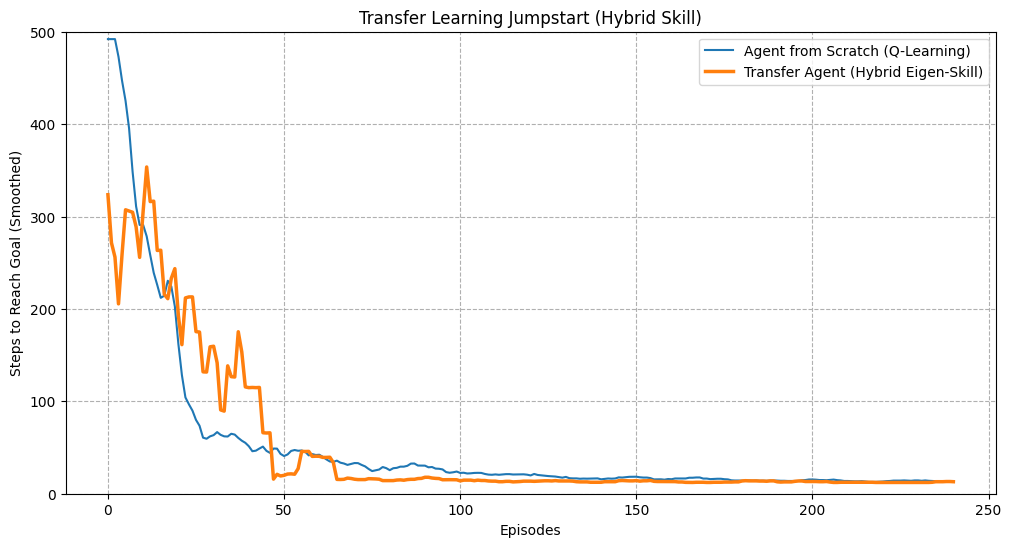

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

# --- Configuration ---

# == Environment (NEW 15x7 grid) ==
NEW_GRID_HEIGHT = 13
NEW_GRID_WIDTH = 18
NEW_WALL_X = 9
NEW_DOOR_POS = (9, 3) # New door position (x, y)
GOAL_POS = (13, 3)    # Fixed goal in the second room
START_POS = (1, 3)    # Fixed start in the first room

# == Skill Loading & Termination ==
SKILL_FILENAME = "hybrid_portable_skill.npy" # File from Step 1
# Old env params needed to reconstruct the agent-space mapping
OLD_GRID_HEIGHT = 10
OLD_GRID_WIDTH = 20
OLD_WALL_X = 11
OLD_DOOR_POS = (11, 5)
# Manual termination for the skill
SKILL_TERMINAL_AGS_COORD = (2, 0) # (dx, dy) = 2 steps past the door

# == Transfer Experiment Params ==
NUM_EPISODES = 250
MAX_STEPS_PER_EP = 500
TF_ALPHA = 0.5 # Learning rate for main task
TF_GAMMA = 0.99
TF_EPSILON_START = 1.0
TF_EPSILON_END = 0.01
TF_EPSILON_DECAY = 0.99


def rebuild_skill_db_from_npy(skill_filename):
    """
    Loads the Q-table array and reconstructs the portable skill dictionary.
    """
    print(f"Loading hybrid skill from {skill_filename}...")

    if not os.path.exists(skill_filename):
        print(f"Error: {skill_filename} not found.")
        print("Please ensure the 'Step 1' script ran successfully.")
        return None

    # 1. Load the raw Q-table array
    q_table_array = np.load(skill_filename)

    # 2. Re-calculate the old env's agent-space ID-to-coordinate mapping
    old_id_to_ags = []
    old_ags_to_id = {}
    for y in range(OLD_GRID_HEIGHT):
        for x in range(OLD_GRID_WIDTH):
            if x == OLD_WALL_X and (x, y) != OLD_DOOR_POS:
                continue
            ags_coord = (x - OLD_DOOR_POS[0], y - OLD_DOOR_POS[1])
            if ags_coord not in old_ags_to_id:
                old_ags_to_id[ags_coord] = len(old_id_to_ags)
                old_id_to_ags.append(ags_coord)

    if len(old_id_to_ags) != q_table_array.shape[0]:
        print("Error: Skill file shape mismatch with old env params.")
        return None

    # 3. Create the portable dictionary {(dx, dy): [q_vals]}
    skill_db = {ags_coord: q_table_array[i]
                for i, ags_coord in enumerate(old_id_to_ags)}

    print(f"Successfully built portable skill DB with {len(skill_db)} agent-space states.")
    return skill_db

class TransferEnv:
    """The NEW 15x7 environment for the transfer task."""
    def __init__(self, width, height, wall_x, door_pos, start_pos, goal_pos):
        self.width = width
        self.height = height
        self.wall_x = wall_x
        self.door_pos_ps = door_pos
        self.start_pos_ps = start_pos
        self.goal_pos_ps = goal_pos
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)} # L, R, U, D
        self._build_mappings()
        self.num_ps_states = len(self.id_to_ps)
        print(f"\nTransfer Env (15x7) Initialized:")
        print(f"  Problem-Space States: {self.num_ps_states}")

    def _build_mappings(self):
        # (Same implementation as previous transfer script)
        self.ps_to_id = {}
        self.id_to_ps = []
        self.ags_to_id = {}
        self.id_to_ags = []
        self.ps_id_to_ags_id = {}
        ps_idx = 0
        for y in range(self.height):
            for x in range(self.width):
                if x == self.wall_x and (x, y) != self.door_pos_ps:
                    continue
                ps_coord = (x, y)
                self.ps_to_id[ps_coord] = ps_idx
                self.id_to_ps.append(ps_coord)
                ags_coord = (x - self.door_pos_ps[0], y - self.door_pos_ps[1])
                if ags_coord not in self.ags_to_id:
                    self.ags_to_id[ags_coord] = len(self.id_to_ags)
                    self.id_to_ags.append(ags_coord)
                self.ps_id_to_ags_id[ps_idx] = self.ags_to_id[ags_coord]
                ps_idx += 1

    def get_ags_coord(self, ps_id):
        """Gets the (dx, dy) coord for a given problem-space state ID."""
        # Check if ps_id is valid before accessing mappings
        if ps_id < 0 or ps_id >= len(self.ps_id_to_ags_id):
             # Handle invalid ps_id, maybe return a default coord or raise error
             print(f"Warning: Invalid ps_id {ps_id} in get_ags_coord")
             # Returning a default or handling depends on expected behavior
             # For now, let's assume it might happen transiently and return a safe default
             return None # Or some default coordinate like (0,0) if appropriate

        ags_map_id = self.ps_id_to_ags_id[ps_id]
        if ags_map_id < 0 or ags_map_id >= len(self.id_to_ags):
             print(f"Warning: Invalid ags_map_id {ags_map_id} for ps_id {ps_id}")
             return None # Or handle appropriately

        return self.id_to_ags[ags_map_id]


    def reset(self):
        return self.ps_to_id[self.start_pos_ps]

    def step(self, ps_id, action):
        # (Same implementation as previous transfer script)
        ps_coord = self.id_to_ps[ps_id]
        dx, dy = self.actions[action]
        next_x, next_y = ps_coord[0] + dx, ps_coord[1] + dy
        next_x = max(0, min(self.width - 1, next_x))
        next_y = max(0, min(self.height - 1, next_y))
        next_ps_coord = (next_x, next_y)
        if next_x == self.wall_x and next_ps_coord != self.door_pos_ps:
            next_ps_coord = ps_coord
        next_ps_id = self.ps_to_id[next_ps_coord]
        done = (next_ps_coord == self.goal_pos_ps)
        reward = 100.0 if done else -1.0
        return next_ps_id, reward, done

class AgentSpaceOption:
    """Wraps the portable skill with the MANUAL termination."""
    def __init__(self, skill_db, terminal_ags_coord):
        self.skill_db = skill_db
        self.terminal_ags_coord = terminal_ags_coord
        self.default_q = np.zeros(4)

    def get_action(self, ags_coord):
        q_vals = self.skill_db.get(ags_coord, self.default_q)
        # Handle cases where all Q-values are zero or non-positive
        if np.all(q_vals <= 0):
             # If no positive action preference, choose randomly or default action
             return random.randint(0, 3) # Example: choose randomly
        return np.argmax(q_vals)


    def is_terminal(self, ags_coord):
        # MANUAL termination override
        return ags_coord == self.terminal_ags_coord

    def is_initiatable(self, ags_coord):
        # Can start if the state is in our DB and not the terminal state
        # Also check if ags_coord is not None
        return ags_coord is not None and (ags_coord in self.skill_db) and (ags_coord != self.terminal_ags_coord)


def run_transfer_experiment(env, use_option, option, num_episodes):
    """Runs the full SMDP Q-Learning experiment."""
    num_actions = 5 if use_option else 4
    agent_name = "Transfer Agent (Hybrid Skill)" if use_option else "Scratch Agent"

    q_table_ps = np.zeros((env.num_ps_states, num_actions))
    steps_per_episode = []
    epsilon = TF_EPSILON_START

    print(f"\n--- Starting Training for {agent_name} ---")
    for ep in range(num_episodes):
        ps_id = env.reset()
        done = False
        total_steps = 0
        while not done and total_steps < MAX_STEPS_PER_EP:
            s_start = ps_id

            # 1. Choose Action
            # Ensure ps_id is valid before accessing Q-table
            if ps_id < 0 or ps_id >= env.num_ps_states:
                 print(f"Error: Invalid state ID {ps_id} encountered. Skipping step.")
                 # Decide how to handle this - break, continue, reset?
                 break # Example: stop episode if state becomes invalid

            if random.random() < epsilon:
                action_choice = random.randint(0, num_actions - 1)
            else:
                action_choice = np.argmax(q_table_ps[ps_id])


            # 2. Execute Action
            if use_option and action_choice == 4: # Action 4 is the option
                ags_coord = env.get_ags_coord(s_start)

                # Add check if ags_coord could be None
                if ags_coord is None:
                     print(f"Warning: Could not get valid ags_coord for state {s_start}. Skipping option.")
                     # Treat as if option was not chosen or handle differently
                     # For now, let's treat it like a failed attempt (similar to not initiatable)
                     reward = -1.0
                     total_steps += 1
                     td_target = reward + TF_GAMMA * np.max(q_table_ps[s_start])
                     q_table_ps[s_start, 4] += TF_ALPHA * (td_target - q_table_ps[s_start, 4])
                     continue # Continue to next step in the episode

                if option.is_initiatable(ags_coord):
                    k, total_option_reward = 0, 0.0
                    current_ps_id = ps_id # Use a temp variable for option execution
                    current_ags_coord = ags_coord

                    while not option.is_terminal(current_ags_coord) and not done and k < 50:
                        primitive_action = option.get_action(current_ags_coord)

                        next_ps_id, reward, done = env.step(current_ps_id, primitive_action)
                        next_ags_coord = env.get_ags_coord(next_ps_id)

                        # Handle possibility of next_ags_coord being None if env logic allows invalid states
                        if next_ags_coord is None:
                             print(f"Warning: Option execution led to invalid state from {current_ps_id}. Breaking option.")
                             break # Exit option execution loop

                        total_option_reward += (TF_GAMMA**k) * reward
                        k += 1
                        current_ps_id = next_ps_id
                        current_ags_coord = next_ags_coord

                    s_next = current_ps_id # Final state after option execution
                    total_steps += k

                    # Ensure s_next is valid before Q-update
                    if s_next < 0 or s_next >= env.num_ps_states:
                         print(f"Error: Option terminated in invalid state {s_next}. Skipping Q-update.")
                    else:
                         q_next_max = np.max(q_table_ps[s_next])
                         td_target = total_option_reward + (TF_GAMMA**k) * q_next_max
                         q_table_ps[s_start, 4] += TF_ALPHA * (td_target - q_table_ps[s_start, 4])

                    ps_id = s_next # Update main ps_id after option execution

                else: # Chose option but not initiatable
                    reward = -1.0
                    total_steps += 1
                    # Ensure s_start is valid before update
                    if s_start >= 0 and s_start < env.num_ps_states:
                         td_target = reward + TF_GAMMA * np.max(q_table_ps[s_start])
                         q_table_ps[s_start, 4] += TF_ALPHA * (td_target - q_table_ps[s_start, 4])
                    # No state change, ps_id remains s_start

            else: # Primitive action
                next_ps_id, reward, done = env.step(ps_id, action_choice)
                s_next = next_ps_id

                # Ensure s_start and s_next are valid before update
                if s_start >= 0 and s_start < env.num_ps_states and \
                   s_next >= 0 and s_next < env.num_ps_states:
                    q_next_max = np.max(q_table_ps[s_next])
                    td_target = reward + TF_GAMMA * (q_next_max if not done else 0)
                    q_table_ps[s_start, action_choice] += TF_ALPHA * (td_target - q_table_ps[s_start, action_choice])

                total_steps += 1
                ps_id = next_ps_id # Update state

        steps_per_episode.append(total_steps)
        epsilon = max(TF_EPSILON_END, epsilon * TF_EPSILON_DECAY)
        if (ep + 1) % 15 == 0:
            print(f"  Ep {ep+1}/{num_episodes}, Steps: {total_steps}")

    return steps_per_episode

def plot_results(results_scratch, results_transfer):
    plt.figure(figsize=(12, 6))
    def smooth(data, k=10):
        if len(data) < k: return data
        return np.convolve(data, np.ones(k)/k, mode='valid')
    plt.plot(smooth(results_scratch), label="Agent from Scratch (Q-Learning)")
    plt.plot(smooth(results_transfer), label="Transfer Agent (Hybrid Eigen-Skill)", linewidth=2.5)
    plt.title("Transfer Learning Jumpstart (Hybrid Skill)")
    plt.xlabel("Episodes")
    plt.ylabel("Steps to Reach Goal (Smoothed)")
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.ylim(0, MAX_STEPS_PER_EP)
    plt.show()

# --- Main execution ---
if __name__ == "__main__":

    # --- Load the portable skill from Step 1 ---
    skill_db = rebuild_skill_db_from_npy(SKILL_FILENAME)

    if skill_db:
        # --- Run the transfer experiment ---
        transfer_env = TransferEnv(NEW_GRID_WIDTH, NEW_GRID_HEIGHT, NEW_WALL_X, NEW_DOOR_POS, START_POS, GOAL_POS)

        # Create the option wrapper with our *manual* termination
        hybrid_option = AgentSpaceOption(skill_db, SKILL_TERMINAL_AGS_COORD)

        # Run both agents
        results_scratch = run_transfer_experiment(transfer_env, use_option=False, option=None, num_episodes=NUM_EPISODES)
        results_transfer = run_transfer_experiment(transfer_env, use_option=True, option=hybrid_option, num_episodes=NUM_EPISODES)

        # --- Plot results ---
        plot_results(results_scratch, results_transfer)
    else:
        print("\nCould not load skill. Transfer experiment aborted.")